# Scientific Programming with Python 
## (Winter 2025/26)

# Session 09: Scikit-Learn


# Plan

- some Python: context managers
- scikit-learn

# Python: Context Manager

* the `with` statement
* manage (external) resources in a program
* setup and teardown phases
* the context manager protocol

See [PEP343](https://peps.python.org/pep-0343/)

## Managing Resources

* (external) resources: files, locks, memory, network connections, computing devices, etc.
* resources need to be allocated before and freed after use:
  - setup phase: open file, setup lock, acquire device, ...
  - teardown phase: close file, release lock, free device, ...
* potential problems: one phase is skipped
  - exception occurs between setup and teardown

#### Example:

In [ ]:
def create_data():
    raise ValueError("Bad Data")

file = open("hello.txt", "w")
file.write(create_data())
file.close()

Problem: the code may never call `file.close`, i.e. leak a file descriptor.

Python offers two ways to deal with this problem:
1. `try...finally` construct
2. `with` construct

In [ ]:
file = open("hello.txt", "w")

try:
    file.write(create_data())
except Exception as e:
    print(f"An error occurred while writing to the file: {e}")
finally:
    # Make sure to close the file after using it
    file.close()

In [ ]:
with open("hello.txt", "w") as file:
    file.write(create_data())

When entering the `with` block:
* the file is opened and assigned to variable `file`
* when the block ends (regularly or by exception) the file is closed

#### Context Manager Example: `Path.open`

In [ ]:
import pathlib

file_path = pathlib.Path("hello.txt")
with file_path.open("w") as file:
    file.write("Hello world")

#### Context Manager Example: `os.scandir`

In [ ]:
import os

with os.scandir(".") as entries:
    for entry in entries:
        print(entry.name, "->", entry.stat().st_size, "bytes")

#### Context Manager Example: `decimal.localcontext`

In [ ]:
from decimal import Decimal, localcontext

with localcontext() as ctx:
    ctx.prec = 42
    print(Decimal("1") / Decimal("42"))

print(Decimal("1") / Decimal("42"))

#### Context Manager Example: `threading.Lock`

In [ ]:
import threading

balance_lock = threading.Lock()

In [ ]:
# Use the try ... finally pattern
balance_lock.acquire()
try:
    print("Update the account balance here ...")
finally:
    balance_lock.release()

In [ ]:
with balance_lock:
    print("Update the account balance here ...")

### Handling exceptions in context managers

While context managers ensure that resources are released in case of an exception, they do not handle the exceptions.

In [ ]:
import pathlib
import logging

file_path = pathlib.Path("hello.txt")

try:
    with file_path.open(mode="w") as file:
        file.write("Hello, World!")
except OSError as error:
    logging.error("Writing to file %s failed due to: %s", file_path, error)

### Using multiple context managers

In [ ]:
with open("hello.txt") as in_file, open("output.txt", "w") as out_file:
    # Read content from in_file
    # Transform the content
    # Write the transformed content to out_file
    pass

## The context manager protocol: `__enter__` and `__exit__`

To implement the context management protocol you need to add both the `__enter__()` and the `__exit__()` special methods to your class:
* `__enter__(self)`: is called when the `with`-statement is executed.  The function may return a value which is then assigned to the target variable of the `with` statement
* `__exit__(self, exc_type, exc_value, exc_tb)`: is called when the `with`-block is left, either regularly (arguments are `None`) or by exception (details are provided as arguments)

In [ ]:
class HelloContextManager:
    def __enter__(self):
        print("Entering the context...")
        return "Hello, World!"

    def __exit__(self, exc_type, exc_value, exc_tb):
        print("Leaving the context...")
        print(exc_type, exc_value, exc_tb, sep="\n")

In [ ]:
with HelloContextManager() as hello:
    print(hello)

Handling of exceptions:

In [ ]:
with HelloContextManager() as hello:
    print(hello)
    hello[100]  # raises an IndexError

* if `__exit__` returns `True`, any exception is swallowed - execution continues after the `with` block
* if `__exit__` returns `False` (or nothing at all), exceptions are propagated out of context

In [ ]:
class HelloContextManager:
    def __enter__(self):
        print("Entering the context...")
        return "Hello, World!"

    def __exit__(self, exc_type, exc_value, exc_tb):
        print("Leaving the context...")
        if isinstance(exc_value, IndexError):
            # Handle IndexError here...
            print(f"An exception occurred in your with block: {exc_type}")
            print(f"Exception message: {exc_value}")
            return True
        return False

In [ ]:
with HelloContextManager() as hello:
    print(hello)
    hello[100]

#### Example: Measuring Execution Time

In [ ]:
from time import perf_counter

class Timer:
    def __enter__(self):
        self.start = perf_counter()
        self.end = 0.0
        return lambda: self.end - self.start

    def __exit__(self, *args):
        self.end = perf_counter()

In [ ]:
from time import sleep

with Timer() as timer:
    # Time-consuming code goes here...
    sleep(0.5)

In [ ]:
timer()

## The standard library `contextlib`

The Python standard library [`contextlib`](https://docs.python.org/3/library/contextlib.html) provides utilities for coding context managers. 

The decorator `contextmanager` allows to turn an apropriately coded generator into a context manager:

In [ ]:
from contextlib import contextmanager

@contextmanager
def hello_context_manager():
    print("Entering the context...")
    yield "Hello, World!"
    print("Leaving the context...")

In [ ]:
with hello_context_manager() as hello:
    print(hello)

Structure of a generator function for `@contextmanager`:
* the function should contain a single `yield` statement
* the code before `yield` is setup code (corresponds to `__enter__`)
* everything after `yield` is the teardown code (corresponds to `__exit__`)

Dealing with exceptions:

In [ ]:
with hello_context_manager() as hello:
    print(hello)
    hello[100]

To deal with exceptions, put `yield` into a `try...finally...` block:

In [ ]:
from contextlib import contextmanager

@contextmanager
def hello_context_manager():
    print("Entering the context...")
    try:
        yield "Hello, World!"
    finally:
        print("Leaving the context...")

In [ ]:
with hello_context_manager() as hello:
    print(hello)
    hello[100]

This allows also for handling exceptions:

In [ ]:
from contextlib import contextmanager

@contextmanager
def hello_context_manager():
    print("Entering the context...")
    try:
        yield "Hello, World!"
    except IndexError as ex:
        print(f"An exception occurred in your with block: {type(ex)}")
        print(f"Exception message: {ex}")
    finally:
        print("Leaving the context...")

In [ ]:
with hello_context_manager() as hello:
    print(hello)
    hello[100]

The library `contextlib` also provides some predfined context managers, e.g. `redirect_stdout`

The following example stores output in the `StringIO` object `f`:

In [ ]:
from contextlib import redirect_stdout
import io

with redirect_stdout(io.StringIO()) as f:
    help(pow)

In [ ]:
print(f.getvalue())

It is also simple to redirect the standard output into a file:

In [ ]:
from contextlib import redirect_stdout

with open('help.txt', 'w') as f, redirect_stdout(f):
    help(pow)

In [ ]:
!cat help.txt

## Summary: context managers

* context managers allow to use the `with` syntax
* compact notation, makes code more readable
* avoid bugs and leaks
* the context manager protocol requires `__enter__` and `__exit__` methods
* the standard library `contextlib` provides means to support for creating context managers

# Machine Learning with **scikit-learn**

In this lecture we will *not* go into any machine learning details or talk about the theoretical background, but
* give you a quick overview of machine learning
* learn how we can do machine learning with python

Install `scikit-learn`

```sh
conda install -c conda-forge scikit-learn
```

![](images/machine_learning_overview.jpg)

## Main steps when working with `scikit-learn`

1. **Import a model class from sklearn**: Models are at the center of Scikit-Learn. They implement the model structure and a learning algorithm

2. **Intialize model with hyperparameters**: A model can be instantiated with different hyperparemters, effecting how it learns from the data.

3. **Prepare the training data**: If we want to do supervised learning then our model learns to predict targets from features, so you have to split data into feature matrix and target vector.

4. **Fit the model to your data by calling the `fit()` method of the model**: This will run the actual machine learning algorithm.

5. **Apply the model to new data**:
  - For supervised learning, often we predict labels for unknown data using the `predict()` method.
  - For unsupervised learning, we often transform or infer properties of the data using the `transform()` or `predict()` method.

# Supvervised Learning

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Regression

We start with a *supervised learning machine learning algorithm*: **Linear Regression**

**step 1:** import a model class from `sklearn`<br>
we import the `LinearRegression` class which allows us to instantiate linea models

In [ ]:
from sklearn.linear_model import LinearRegression

**step 2:** intialize model with hyperparameters<br>
we set `fit_intercept`to `True` which tells to model to also learn a parameter for the `intercept`

In [ ]:
model = LinearRegression(fit_intercept=True)

**step 3:** split data into `feature` matrix and `target` vector<br>
for this step we will create some toy data

In [ ]:
np.random.seed(0)

feature_x = np.linspace(start=0, stop=10, num=50)
target_y = 2 * feature_x + np.random.randint(low=-4, high=4, size=len(feature_x))

# model.fit will expect a 2d array for x, so we add a dummy dimension 
# so e.g. [1,2,3] becomes [[1], [2], [3]]
feature_x = np.expand_dims(feature_x, axis=1)

plt.scatter(feature_x, target_y);

**step 4:** fit the model to our data by calling the `fit()` method of the model.<br>
the parameters that our model learns are the `intercept` and `slope`(coefficient) of a linear function.

In [ ]:
model.fit(feature_x, target_y)
model.coef_, model.intercept_

**step 5:** Apply the model to new data.


In [ ]:
feature_x_new = np.linspace(start=-5, stop=15, num=20)
y_predicted = model.predict(np.expand_dims(feature_x_new, axis=-1))

plt.scatter(feature_x, target_y)
plt.scatter(feature_x_new, y_predicted);
plt.plot(feature_x_new, y_predicted, color="orange")

## Classification

### Classification Example 1: Decision Trees

**step 1:** import a model class from `sklearn`<br>

In [ ]:
from sklearn.tree import DecisionTreeClassifier

**step 2:** intialize model with hyperparameters<br>


In [ ]:
model = DecisionTreeClassifier()

**step 3:** Prepare the training data.  We will use the famous Iris dataset, which is provided by Scikit-Learn:

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
type(iris)

We can split the data into `feature` matrix $X$ and `target` vector $y$:

In [ ]:
iris.data.shape, iris.target.shape

In [ ]:
# look at the data
iris.data[:5]

In [ ]:
iris.target

In [ ]:
# look at the column names
iris.feature_names

In [ ]:
# look at target names
iris.target_names

We can create a pandas `DataFrame` from the `iris` data:

In [ ]:
iris_dataframe = load_iris(as_frame=True).data
iris_dataframe

Before training, we have a look at the dataset. Here we can already see that there are clusters that can be used for classification.

In [ ]:
sns.scatterplot(data=iris_dataframe, x="sepal width (cm)", y="petal width (cm)", hue=iris.target)

Now finish **step 3** by splitting data into feature matrix and target vector

In [ ]:
# split dataset into data and target
X = iris.data
y = iris.target

**step 4:** fit the model to our data by calling the `fit()` method of the model.

In [ ]:
model.fit(X, y);

**step 5:** Apply the model to "new" data.

In [ ]:
model.predict([X[20]])

In [ ]:
y[20]

**Bonus**: output the decision tree

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(16,10))
plot_tree(model, filled=True, proportion=True);

### Classifier Example 2: K-nearest Neighbors

K-nearest Neighbors (knn) is a rather simple machine learning algorithm that can be used for regression and classification, though it is usually used as a classification algorithm.  

__How does it work?__  
* classify an unknown datapoint by looking at the $k$ nearest datapoints
* assign it then to the class to which the most of its nearest neighbors belong.

Note:
* Finding the right parameter for k is often the crux of knn.
* A method to test several different k values on one dataset is *cross-validation* (later)

Remark: The _distance_ to the different points can be calculated with different measurements:
- the manhatten distance
- the euclidean distance
- the hamming distance  

[Here you can test out how the knn works](http://vision.stanford.edu/teaching/cs231n-demos/knn/)

**step 1:** import a model class from `sklearn`

In [ ]:
# load knn
from sklearn.neighbors import KNeighborsClassifier

**step 2:** intialize model with hyperparameters

In [ ]:
# use the model with k = 5
knn = KNeighborsClassifier(n_neighbors = 5)

**step 3:** Prepare the training data.  We will again use the Iris dataset:

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target

**step 4:** fit the model to our data by calling the `fit()` method of the model.

In [ ]:
knn.fit(X,y);

**step 5:** Apply the model to "new" data.

In [ ]:
# test the result:
classes = {0: "setosa", 1: "versicolor", 2: "virginica"}
x_unknown = [[6,2.5, 4, 3]]
prediction = knn.predict(x_unknown)

classes[prediction[0]]

### Exercise: Train a Support Vector Machine on the Iris dataset

The Support Vector Machine (SVM) is a prominent classifier in machine learning, with a rich theoretical basis.
Scikit-Learn provides a [Support Vector Machine Model](https://scikit-learn.org/stable/modules/svm.html).  Use that model to perform the five steps.

# Unsupervised learning

* draw inferences from datasets consisting of input data without labeled response (unlabeled data)
* aims at understanding the structure or distribution of the data
* applications
  - compression
  - feature extraction
  - generative models

## Clustering

__What is clustering ?__

Divide the population/data points into a number of groups such that data points in the same groups are 
- more similar to other data points in the same group and
- dissimilar to the data points in other groups.

There are no general criteria for good clustering. It depends on the use case, what is the criteria may be applied, e.g. with respect to number and shape of clusters, type of similarity.

__Types of Clustering__

Broadly speaking, clustering can be divided into two subgroups :

- __Hard Clustering:__ In hard clustering, each data point either belongs to a cluster completely or not. 
- __Soft Clustering:__ In soft clustering, instead of putting each data point into a separate cluster, a probability or likelihood of that data point to be in those clusters is assigned.

Some common applications for clustering include the following:

- market segmentation
- social network analysis
- search result grouping
- medical imaging
- fraud detection
- image segmentation
- anomaly detection

## Introduction to K-Means

The **k-means** algorithm searches for a pre-determined number of clusters within an unlabeled multidimensional dataset. It accomplishes this using a simple conception of what the optimal clustering looks like:

The "cluster center" is the arithmetic mean of all the points belonging to the cluster.
Each point is closer to its own cluster center than to other cluster centers.
Those two assumptions are the basis of the k-means model. We will soon dive into exactly how the algorithm reaches this solution, but for now let's take a look at a simple dataset and see the k-means result.

First, let's generate a two-dimensional dataset containing four distinct blobs. To emphasize that this is an unsupervised algorithm, we will leave the labels out of the visualization

**step 1:** import a model class from `sklearn`

In [ ]:
from sklearn.cluster import KMeans

**step 2:** intialize model with hyperparameters

In [ ]:
# defining the k neighbours
kmeans = KMeans(n_clusters=4)

**step 3:** Prepare the training data.  We will use the function `make_blobs()` to create a dataset with cluster structure:

In [ ]:
from sklearn.datasets import make_blobs

# creating the data points
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)

Visualize the dataset to get an impression of how the clusters look:

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

#plotting the dat values
plt.scatter(X[:, 0], X[:, 1], s=50);

By eye, it is relatively easy to pick out the four clusters. The k-means algorithm does this automatically, and in Scikit-Learn uses the typical estimator API:

**step 4:** fit the model to our data by calling the `fit()` method of the model.

In [ ]:
# fitting the data point inside the model
kmeans.fit(X);

**step 5:** Use the trained model for prediction

In [ ]:
# predecting the clusters
y_kmeans = kmeans.predict(X)

Let's visualize the results by plotting the data colored by these labels. We will also plot the cluster centers as determined by the k-means estimator:

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.show()

## Loading Datasets

* Scikit-learn comes with a bunch of small dataset. They were downloaded when you installed the library.
* Additionally sklearn offers a utility for directly downloading datasets from the OpenML database, in an sklearn-friendly format.

See [Scikit-Learn Documentation on Datasets](https://scikit-learn.org/stable/datasets.html) for more information.

### Preinstalled Datasets
The digits dataset is a smaller (and easier) version of the famous MNIST handwrittten digits dataset. It contains digits written in human handwriting as data and the value of the respective digits as targets. Teaching an machine learning model to read human handwriting is a very typical task in the field of computer vision.

The data will be loaded as a sklearn ``Bunch`` object, which is more or less a fancy dictionary.

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()

print(type(digits),'\n')
print(digits.keys(),'\n')

In [ ]:
print(digits.DESCR)

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green')

### Splitting the dataset

To assess the performance, we need a set of fresh (!) data. Split the dataset into two parts:
* train set: these data are used for training (fitting the model)
* test set: these data are used for assessing the performance of the trained model (testing the model)

The test data must not be used during training - the test has to be performed on data the model has not seen before.

!-[image.png](attachment:d14b8d68-f76c-4166-aabc-b6ea2ff7f62b.png)
MIT License, Copyright (c) 2020 Michael Galarnyk, https://github.com/mGalarnyk
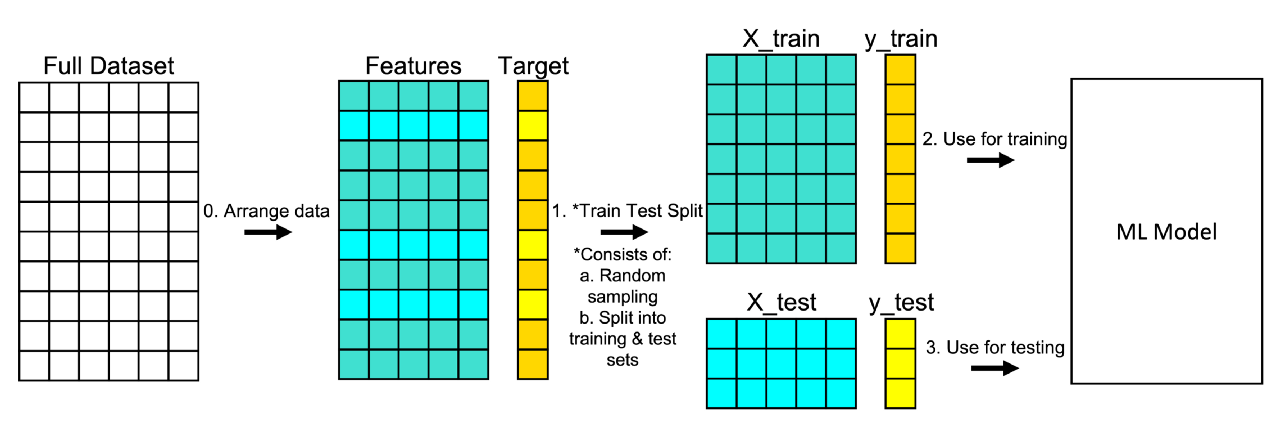

Scikit-Learn provides the function `train_test_split()` to split a given dataset:

In [ ]:
from sklearn.model_selection import train_test_split

X = digits.data
y = digits.target
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=0);

The data is used to train a naive Bayes classifier. This classifier is just a (simple) example at this point, so you don't need to wrap your head around that.

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(Xtrain, ytrain)
y_model = model.predict(Xtest)

In [ ]:
print("model prediction:", y_model[0])
plt.imshow(Xtest[0].reshape((8,8)), cmap='binary', interpolation='nearest')

## Evaluation

The test data can be used to assess the performance of the model.  Classifiers are typically evaluated based on the *confusion matrix* and derived metrics like *accuracy*, *precision*, and *recall*:

In [ ]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(ytest, y_model)

sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted value')
plt.ylabel('true value');

The metrics are provided as well:

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(ytest, y_model))

Is this a good or bad value?
- it is above chance level (10%)
- it is below theoretical optimum (100%)

Compare with other classifiers:

Any classifier from scikit-learn can be trained with this data.

In [ ]:
from sklearn.svm import SVC

clf = SVC()
clf.fit(Xtrain, ytrain)
y_model = clf.predict(Xtest)
accuracy_score(ytest, y_model)

In [ ]:
mat = confusion_matrix(ytest, y_model)

sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted value')
plt.ylabel('true value');

### Downloading datasets
Most real datasets are too big to be part of the library itself. Sklearn offers a function for downloading any dataset from [openml.org](https://openml.org/) in a sklearn friendly format. Here we will download the actual MNIST dataset. It contains 70.000 examples, so downloading it might take a bit.

In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml(name='mnist_784')

In [ ]:
print(mnist.keys(), "\n")

In [ ]:
print(mnist.DESCR)

Train a model on that dataset:

In [ ]:
from sklearn.naive_bayes import GaussianNB

X = mnist.data
y = mnist.target
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=0)

model = GaussianNB()
model.fit(Xtrain, ytrain)
y_model = model.predict(Xtest)

... and evaluate its performance:

In [ ]:
print("Accuracy:", accuracy_score(ytest, y_model))

mat = confusion_matrix(ytest, y_model)

sns.heatmap(mat, square=True, annot=True, cbar=False, fmt='g')
plt.xlabel('predicted value')
plt.ylabel('true value');

### Exercise: 

Compare these results with
1. A k-NN classifier
2. A support vector machine

## Cross-validation

When adapting hyperparameters (e.g. $k$ in $k$-NN classifier), one needs a way to check which works best.
* evaluation on a validation set
  - this must not be done on the test set, as hyperparameter adaptation is part of training/model selection
* another train-validation split may work for large datasets
* for smaller datasets, there is the risk of *overfitting* on the train set: use of features that are specific to the train set

Cross-validation is a method with which you can validate and train on the whole (train) dataset.

### K-fold cross-validation

In k-fold cross-validataion you split the data into $k$-folds. After this:
- the model is trained on $k-1$ folds
- the resulting model is tested with the remaining data fold 

This is repeated $k$-times in a loop. After this the model performance is estimated as the average of all values computed in the loop.

![](images/k-fold-cv.png)

Image from [scikit learn](https://scikit-learn.org/stable/modules/cross_validation.html)

In [ ]:
# first we take the iris data set:
from sklearn.datasets import load_iris
iris = load_iris()

# X is the data and y the target:
X = iris.data
y = iris.target

Now evaluate different hyperparameters by cross-validation on the dataset. We use $k$-NN and investigate the influence of the number of neighbors $k$:

In [ ]:
# we need to import cross_val_score from model selection
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# we first select which k-values we want to test and create an empty array for the scores
k_values = [i for i in range (1,15)]
scores = np.zeros(15)

# then we iterate through all the k-values and perform crossvalidation
for k in k_values:
    # initialize the model
    knn = KNeighborsClassifier(n_neighbors = k)

    # calculate the score with cross_val_score
    score = cross_val_score(knn, X, y, cv=5)  # cv=5 is number of folds
    scores[k] = np.mean(score)

print(f"{np.mean(scores):.4f} accuracy with a standard deviation of {np.std(scores):.4f}")
print(f"max_score {np.max(scores):.4f} for k={np.argmax(scores)}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(k_values, scores[1:])
plt.xlabel("k"); plt.ylabel("avearage accuracy"); plt.ylim(.94,1.0)
plt.show()